# Explore Uganda Admin Boundaries

Load the downloaded Uganda administrative boundaries, inspect the district layer, select three districts, and visualize the dissolved area of interest.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from erw_mrv.boundaries import (
    DISTRICT_NAME_FIELD,
    PROJECTED_CRS,
    UGANDA_DISTRICTS,
    filter_districts,
    make_district_aoi,
    union_geometries,
)

plt.rcParams["figure.figsize"] = (10, 8)

## Load District Boundaries

In [2]:
districts = gpd.read_file(UGANDA_DISTRICTS)
districts.info()
districts[["adm2_name", "adm2_pcode", "adm1_name", "area_sqkm", "geometry"]].head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   adm2_name   135 non-null    str           
 1   adm2_name1  0 non-null      object        
 2   adm2_name2  0 non-null      object        
 3   adm2_name3  0 non-null      object        
 4   adm2_pcode  135 non-null    str           
 5   adm1_name   135 non-null    str           
 6   adm1_name1  0 non-null      object        
 7   adm1_name2  0 non-null      object        
 8   adm1_name3  0 non-null      object        
 9   adm1_pcode  135 non-null    str           
 10  adm0_name   135 non-null    str           
 11  adm0_name1  0 non-null      object        
 12  adm0_name2  0 non-null      object        
 13  adm0_name3  0 non-null      object        
 14  adm0_pcode  135 non-null    str           
 15  valid_on    135 non-null    datetime64[ms]
 16  valid_to    0 non-

,adm2_name,adm2_pcode,adm1_name,area_sqkm,geometry
0,Abim,UG3064,Northern,2752.061404,"POLYGON ((33.58099 3.14912, 33.58555 3.14702, ..."
1,Adjumani,UG3065,Northern,3113.726677,"POLYGON ((32.04597 3.58896, 32.04578 3.58875, ..."
2,Agago,UG3066,Northern,3513.693871,"POLYGON ((33.41652 3.30434, 33.41701 3.30403, ..."
3,Alebtong,UG3067,Northern,1555.808581,"POLYGON ((33.03629 2.5013, 33.03664 2.50075, 3..."
4,Amolatar,UG3068,Northern,1795.916068,"POLYGON ((32.9014 1.8057, 32.90231 1.80568, 32..."


In [3]:
print(f"District count: {len(districts)}")
print(f"CRS: {districts.crs}")
districts[DISTRICT_NAME_FIELD].sort_values().tolist()[:10]

District count: 135
CRS: EPSG:4326


['Abim',
 'Adjumani',
 'Agago',
 'Alebtong',
 'Amolatar',
 'Amudat',
 'Amuria',
 'Amuru',
 'Apac',
 'Arua']

## Choose Three Districts

Edit this list to the three districts you want to process.

In [4]:
SELECTED_DISTRICTS = ["Masindi", "Mubende", "Kibaale", "Kakumiro", "Kagadi", "Kyankwanzi", "Kiboga", "Kyenjojo"]

selected = filter_districts(districts, SELECTED_DISTRICTS)
selected[["adm2_name", "adm2_pcode", "adm1_name", "area_sqkm", "geometry"]]

,adm2_name,adm2_pcode,adm1_name,area_sqkm,geometry
89,Masindi,UG4125,Western,3922.836039,"POLYGON ((31.75038 2.29649, 31.74935 2.22361, ..."
98,Mubende,UG1020,Central,2711.408638,"POLYGON ((31.45689 0.86458, 31.45808 0.86451, ..."
60,Kibaale,UG4117,Western,1164.911124,"POLYGON ((31.12076 1.00734, 31.12068 1.00644, ..."
43,Kakumiro,UG4112,Western,1667.346299,"POLYGON ((31.23959 1.21715, 31.2405 1.21661, 3..."
42,Kagadi,UG4111,Western,1554.242737,"POLYGON ((30.66504 1.11919, 30.66605 1.11878, ..."
75,Kyankwanzi,UG1012,Central,2464.011815,"POLYGON ((31.56979 1.36364, 31.57062 1.36318, ..."
61,Kiboga,UG1011,Central,1573.937674,"POLYGON ((31.92861 1.08321, 31.93063 1.08161, ..."
77,Kyenjojo,UG4124,Western,2345.927476,"POLYGON ((30.56081 0.94069, 30.56131 0.94049, ..."


## Visualize Selected Districts

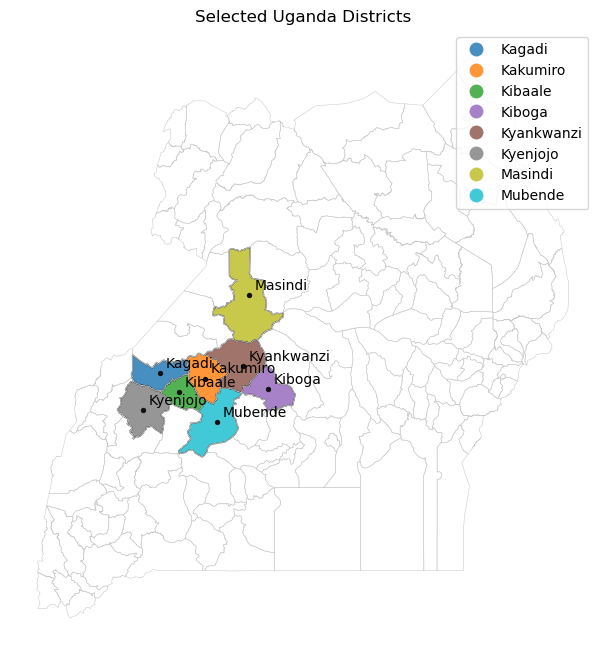

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
districts.boundary.plot(ax=ax, color="#c7c7c7", linewidth=0.35)
selected.plot(
    ax=ax,
    column=DISTRICT_NAME_FIELD,
    categorical=True,
    legend=True,
    edgecolor="#202020",
    linewidth=0.8,
    alpha=0.82,
)
selected.representative_point().plot(ax=ax, color="#111111", markersize=8)

for _, row in selected.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(row[DISTRICT_NAME_FIELD], xy=(point.x, point.y), xytext=(4, 4), textcoords="offset points")

ax.set_title("Selected Uganda Districts")
ax.set_axis_off()
plt.show()

## Dissolve Into AOI

In [6]:
selected_projected = selected.to_crs(PROJECTED_CRS)
aoi_geometry = union_geometries(selected_projected.geometry)
aoi = gpd.GeoDataFrame(
    {
        "districts": [", ".join(selected[DISTRICT_NAME_FIELD].tolist())],
        "district_count": [len(selected)],
        "area_km2_calc": [aoi_geometry.area / 1_000_000],
    },
    geometry=[aoi_geometry],
    crs=selected_projected.crs,
)
aoi[["districts", "district_count", "area_km2_calc", "geometry"]]

,districts,district_count,area_km2_calc,geometry
0,"Masindi, Mubende, Kibaale, Kakumiro, Kagadi, K...",8,17405.913158,"POLYGON ((350281.289 90067.425, 350276.695 899..."


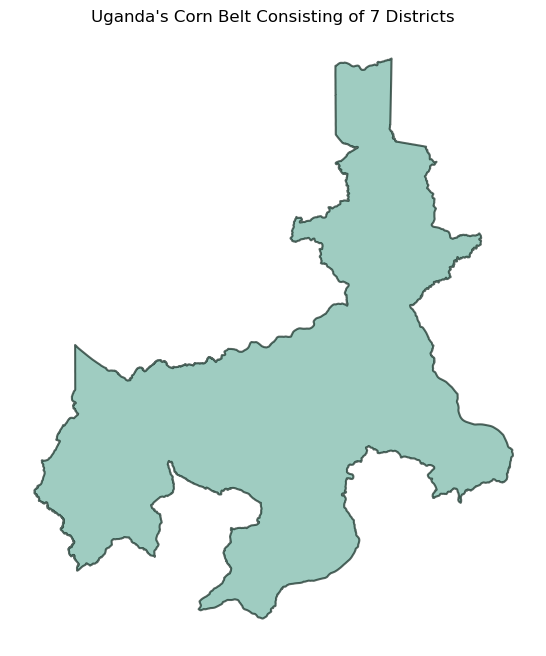

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
aoi.plot(ax=ax, facecolor="#77b7a7", edgecolor="#102820", linewidth=1.5, alpha=0.7)
ax.set_title("Uganda's Corn Belt Consisting of 7 Districts")
ax.set_axis_off()
plt.show()

## Write Processed Boundary Files

In [8]:
outputs = make_district_aoi(SELECTED_DISTRICTS)
outputs

{'districts': PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/boundaries/selected_districts.gpkg'),
 'aoi': PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/boundaries/selected_districts_aoi.gpkg'),
 'aoi_geojson': PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/boundaries/selected_districts_aoi.geojson')}